In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 1.4
Number of features: 128


In [7]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
for df in [s25_pts, s24_pts]:
    df['BLOWOUT_RISK'] = (abs(df['spread']) >= 10).astype(int)
    df['COMPETITIVE_GAME'] = (abs(df['spread']) < 5).astype(int)
    df['TEAM_IMPLIED_PTS'] = ((df['total'] + df['team_spread']) / 2).round(1)
df = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')
df.sample()

,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS

In [5]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


C:\Users\alexg\AppData\Local\Temp\ipykernel_38004\2718787215.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
77534,77534,77534,77534,Moussa Diabate,player_points,prizepicks,over,8.5,-137,Orlando Magic,Charlotte Hornets,NaN,NaN,2025-02-13,game,8.5,105.0,over
22115,22115,22115,22115,Darius Garland,player_points,prizepicks,under,20.5,-137,Cleveland Cavaliers,Washington Wizards,476416aa38d1c8fb8a9bfc5ae8fe6251,2024-12-04T00:10:00Z,2024-12-03,NaN,NaN,NaN,under
18948,18948,18948,18948,Victor Wembanyama,player_points,prizepicks,under,26.5,-137,Utah Jazz,San Antonio Spurs,0a3002d2aaa7b94c5c9c4d3bf792ac7d,2024-11-27T02:00:00Z,2024-11-26,NaN,NaN,NaN,under
17410,17410,17410,17410,Walker Kessler,player_points,prizepicks,under,7.5,-137,Utah Jazz,New York Knicks,b260c49ab9337ae42774bb3b1531a915,2024-11-23T22:10:00Z,2024-11-23,NaN,NaN,NaN,under
67155,67155,67155,67155,Myles Turner,player_points,prizepicks,over,14.5,-137,Los Angeles Clippers,Indiana Pacers,NaN,NaN,2025-02-07,game,14.0,100.0,over


In [17]:
date = '2025-03-22'

results = backtestPairs(
    data=df,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=0.18, 
    top_n=10, 
    variance_inflation=1.1, 
    distribution_type='t', stat_col='PTS', 
    use_monte_carlo=True, n_simulations=10000, max_kelly=0.25, stake=10)

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum()
    avg_profit = results['pair_profit'].mean()
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2025-03-22
Time taken for pairs: 4.872414827346802 seconds
Time taken for sorting: 4.873416900634766 seconds
Time taken for dropping duplicates: 4.875418424606323 seconds
Time taken for iterating over evData: 4.875418424606323 seconds
Time taken for backtest_results: 4.90598726272583 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 10
Wins: 0
Win Rate: 0.00%
Total Profit: $-100.00
Average Profit per Bet: $-10.00


,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Draymond Green,Mouhamed Gueye,9.5,4.5,13.36,10.69,over,over,0.730,0.865,0.6320,0.152,0.287,0.298,8.96,0.448,1,27.89,23.34,7.42,6.45,High,High,89.6,Monte Carlo,5,2,0,0,0,1,-10.0,top_ev,2025-03-22
1,Pascal Siakam,Mouhamed Gueye,20.5,4.5,18.15,10.69,under,over,0.650,0.865,0.5625,0.072,0.287,0.228,6.88,0.344,1,29.88,23.34,7.62,6.45,High,High,68.8,Monte Carlo,26,2,0,0,0,1,-10.0,top_ev,2025-03-22
2,Draymond Green,Zaccharie Risacher,9.5,11.5,13.36,15.48,over,over,0.730,0.724,0.5289,0.152,0.146,0.195,5.87,0.293,1,27.89,30.84,7.42,7.87,High,High,58.7,Monte Carlo,5,14,0,1,0,1,-10.0,top_ev,2025-03-22
3,Dyson Daniels,Draymond Green,13.5,9.5,17.23,13.36,over,over,0.718,0.730,0.5241,0.139,0.152,0.190,5.72,0.286,1,29.97,27.89,7.65,7.42,High,High,57.2,Monte Carlo,12,5,0,0,0,1,-10.0,top_ev,2025-03-22
4,Tyrese Martin,Mouhamed Gueye,11.5,4.5,10.04,10.69,under,over,0.603,0.865,0.5219,0.025,0.287,0.188,5.66,0.283,1,24.42,23.34,7.34,6.45,High,High,56.6,Monte Carlo,9,2,1,0,0,1,-10.0,top_ev,2025-03-22
5,Brandin Podziemski,Mouhamed Gueye,14.5,4.5,13.03,10.69,under,over,0.596,0.865,0.5159,0.018,0.287,0.182,5.48,0.274,1,28.82,23.34,8.06,6.45,High,High,54.8,Monte Carlo,19,2,0,0,0,1,-10.0,top_ev,2025-03-22
6,Tyrese Haliburton,Mouhamed Gueye,16.5,4.5,15.12,10.69,under,over,0.594,0.865,0.5142,0.016,0.287,0.180,5.42,0.271,1,30.13,23.34,7.69,6.45,High,High,54.2,Monte Carlo,16,2,1,0,0,1,-10.0,top_ev,2025-03-22
7,Trae Young,Draymond Green,24.5,9.5,28.96,13.36,over,over,0.698,0.730,0.5095,0.119,0.152,0.175,5.28,0.264,1,39.45,27.89,10.06,7.42,High,High,52.8,Monte Carlo,25,5,1,0,0,1,-10.0,top_ev,2025-03-22
8,Noah Clowney,Mouhamed Gueye,9.5,4.5,8.44,10.69,under,over,0.580,0.865,0.5019,0.002,0.287,0.168,5.06,0.253,1,22.23,23.34,7.04,6.45,High,High,50.6,Monte Carlo,5,2,1,0,0,1,-10.0,top_ev,2025-03-22
9,Buddy Hield,Mouhamed Gueye,10.5,4.5,9.39,10.69,under,over,0.579,0.865,0.5011,0.001,0.287,0.167,5.03,0.252,1,24.03,23.34,7.47,6.45,High,High,50.3,Monte Carlo,5,2,1,0,0,1,-10.0,top_ev,2025-03-22


## Points

In [8]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=df,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.10, 
        top_n=20, 
        variance_inflation=1.1, 
        distribution_type='t', stat_col='PTS', 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=10)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Time taken for pairs: 2.2075445652008057 seconds
Time taken for sorting: 2.2085535526275635 seconds
Time taken for dropping duplicates: 2.210561990737915 seconds
Time taken for iterating over evData: 2.210561990737915 seconds
Time taken for backtest_results: 2.264683485031128 seconds
  ✓ Processed 20 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Time taken for pairs: 9.549552202224731 seconds
Time taken for sorting: 9.549552202224731 seconds
Time taken for dropping duplicates: 9.552062034606934 seconds
Time taken for iterating over evData: 9.552062034606934 seconds
Time taken for backtest_results: 9.602641105651855 seconds
  ✓ Processed 20 bets
Processing 2024-10-24... 3/163
Starting backtest for pairs on 2024-10-24
Time taken for pairs: 4.4566943645477295 seconds
Time taken for sorting: 4.458200931549072 seconds
Time taken for dropping duplicates: 4.460214138031006 seconds
Time tak

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 2,712
   Wins: 1,047
   Hit Rate: 38.61%
   Total Profit: $2,145.00
   Total Staked: $13,560.00
   ROI: 15.82%
   Volatility: $65.70
   Max Drawdown: $-515.00
   Sharpe Ratio: 4.586

   PROBABILITY METRICS:
   Brier Score: 0.2626 (lower is better)
   Log Loss: 0.7241 (lower is better)
   AUC-ROC: 0.5784 (higher is better)
   Samples: 2712

 RECOMMENDED BETS ANALYSIS (Edge > 0.20):
   Total Bets: 5
   Wins: 2
   Hit Rate: 40.00%
   Total Profit: $5.00
   Total Staked: $25.00
   ROI: 20.00%
   Volatility: $8.22
   Max Drawdown: $-5.00
   Sharpe Ratio: 2.325

   PROBABILITY METRICS:
   Brier Score: 0.2124 (lower is better)
   Log Loss: 0.6174 (lower is better)
   AUC-ROC: 0.8333 (higher is better)
   Samples: 5


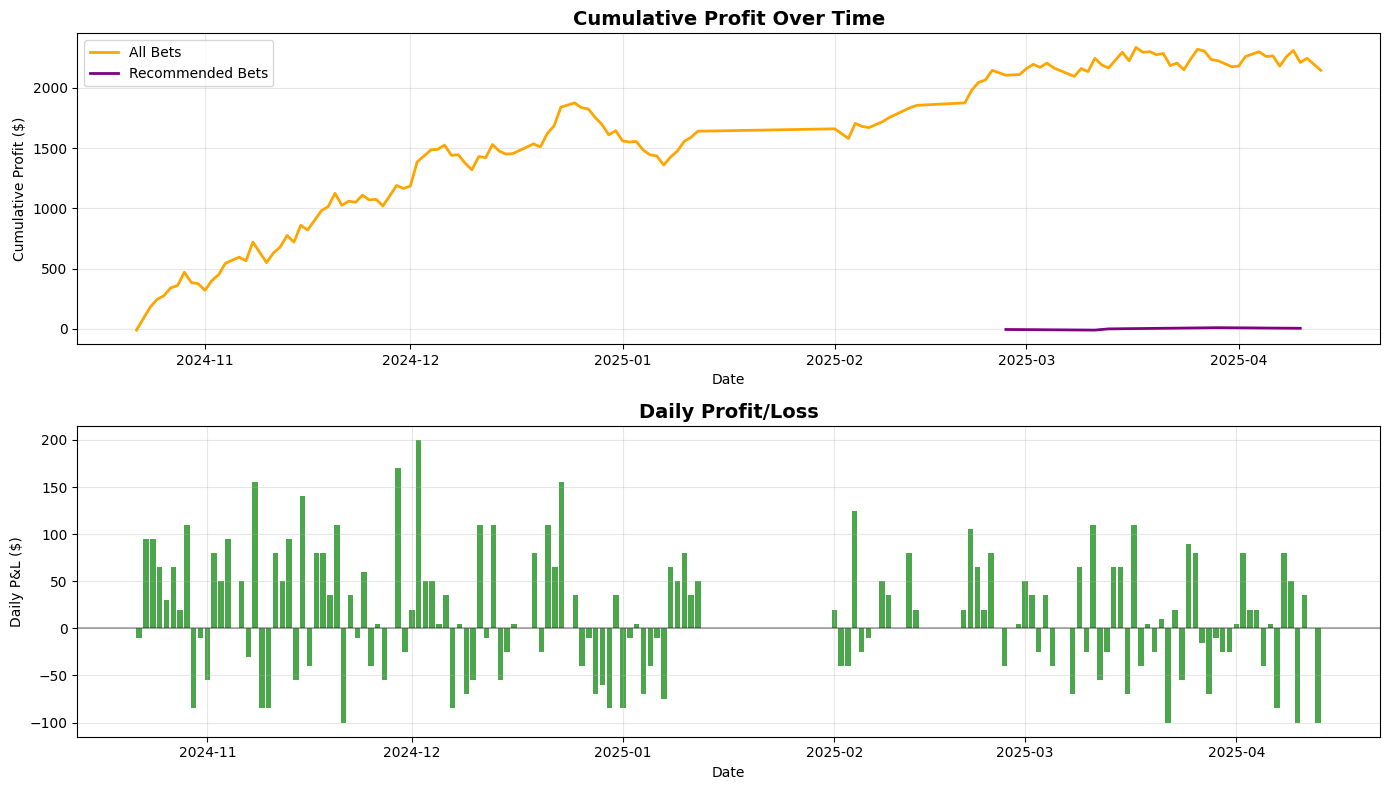

In [9]:
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.20):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics for recommended bets
    if 'probability_metrics' in rec_metrics and 'error' not in rec_metrics['probability_metrics']:
        prob_metrics = rec_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()